# Antibiotic heteroresistance generated by plasmid copy-number variability
## Supplementary figure 4


### Fitness Cost - PCN


## System preparation


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde


In [22]:
%load_ext rpy2.ipython

### Mounting Gdrive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### File paths

In [4]:
rootDir="/content/drive/MyDrive/SYNC_Projects/"

rootDir=rootDir+"pBGT/ms/"

workingDir=rootDir+"code/Supplementary/"
data_path=rootDir+"data/supplementary/sFig-12/"

sfig_path=rootDir+"figures/SuppFigures/"


In [10]:

filename=data_path+"all_strains_vmax.csv"
many_fits_single_res=pd.read_csv(filename,sep="\t")

display(many_fits_single_res.head(2))

single_strains=["WT","MGGT","pBGT","G54U","G55U"]

,strain,replicate,y0,mumax,r2
0,G54U,1,0.045912,0.354063,0.999748
1,G55U,1,0.048437,0.344448,0.999680


[[0.5053147675245413, 0.4795852742315454, 0.5042269154695419, 0.4882261283792586, 0.4958154921494138, 0.3648599494758995], [0.4561962213847961, 0.4764880843760916, 0.4879038621749254, 0.4870250969360053, 0.4894973385897749, 0.4169148948628048], [0.3728757865388414, 0.4353525749289464, 0.3338596548104364, 0.4328077025482525, 0.4390811080611627, 0.4170442989744999], [0.3540627706712143, 0.3674200301581047, 0.3150140620747365, 0.3614740151450279, 0.3417093725365889, 0.3239538250414796], [0.344448497139639, 0.3363223695415798, 0.3543259663155997, 0.3515832900012044, 0.360222886375355, 0.3618853353019421]]


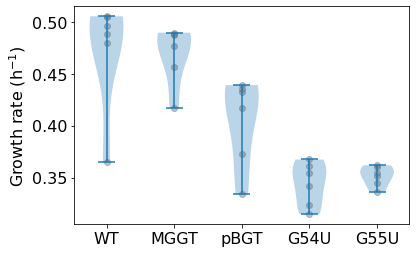

In [11]:


fig=plt.figure(figsize=(6,4))
fig.set_facecolor('white')
plt.rcParams.update({'font.size': 16})

xx=[]
mumaxs=[]

for istrain,this_strain in enumerate(single_strains):
    this_df=many_fits_single_res[many_fits_single_res["strain"]==this_strain]
    this_mumaxs=list(this_df["mumax"])
    this_x=[istrain]*len(this_mumaxs)
    xx.append(this_x)
    mumaxs.append(this_mumaxs)
    plt.scatter(this_x,this_mumaxs,alpha=.5,c='gray')
print(mumaxs)


plt.violinplot(mumaxs,positions=range(0,5))
#plt.boxplot(yy,positions=range(0,5))
plt.xticks(range(0,5),labels=single_strains)
plt.ylabel("Growth rate (h$^{-1}$)")


plt.show()


In [12]:
ref_mumax=np.mean(mumaxs[1])   ###<-- relative to MGGT
relative_fitness_mumax_mean=[]
relative_fitness_mumax_std=[] 
fitness_costs_mumaxs=[]
for i,strain in enumerate(single_strains):
    this_mumaxs=mumaxs[i]
    this_mean=np.mean(this_mumaxs)
    this_sd=np.std(this_mumaxs)
    rel_mean=this_mean/ref_mumax
    rel_sd=this_sd/ref_mumax
    relative_fitness_mumax_mean.append(rel_mean)
    relative_fitness_mumax_std.append(rel_sd)
    fitness_costs_mumaxs.append(1-rel_mean)
    print(strain,this_mean,this_sd,"\t",rel_mean,rel_sd)
fitness_costs_mumaxs

WT 0.4730047545383667 0.04917550600616555 	 1.0085297837280063 0.10485087509430231
MGGT 0.469004249720733 0.02593346370100279 	 1.0 0.055294730733132555
pBGT 0.4051701876436899 0.038931294634430756 	 0.8638944911159059 0.08300840484411871
G54U 0.34393901260452536 0.01915879587706032 	 0.7333387976960181 0.04084994088746181
G55U 0.3514647241125533 0.008869551393061517 	 0.7493849454921395 0.018911452078190893


[-0.00852978372800628,
 0.0,
 0.13610550888409412,
 0.26666120230398194,
 0.2506150545078605]

## Plot Strains PCN vs Fluorescence

In [14]:
strains_file=data_path+"strains_characterization_pBGT_evo.txt"
strains_file

'/content/drive/MyDrive/SYNC_Projects/pBGT/ms/data/supplementary/sFig-12/strains_characterization_pBGT_evo.txt'

### read files

In [15]:
dfstr=pd.read_csv(strains_file,sep='\t',dtype=str)
dfstr

,Strain name,Fitness *,PCN,CMI CAZ (mg l-1),CMI AMP (mg l-1)
0,MG,1.003 ± 0.011,NaN,0.25,4
1,MG::blaTEM-1,NaN,NaN,0.25,512
2,MG/pBGT,0.943 ± 0.013,19.12 ± 1.56,0.5,"8,192"
3,MG::blaTEM-1 R146,1.008 ± 0.011,NaN,0.5,128
4,MG/pBGT R164S,0.943 ± 0.003,21.10 ± 0.85,64,"4,096"
5,MG/pBGT G54U,0.793 ± 0.019,44.50 ± 3.81,0.5,"32,768"
6,MG/pBGT G55U,0.557 ± 0.116,88.93 ± 15.65,1,"32,768"
7,MG/pBGT R164S G54U,0.762 ± 0.016,52.30 ± 2.19,128,"4,096"
8,MG/pBGT R164S G55U,0.509 ± 0.082,127.29 ± 4.58,128,"8,192"


In [16]:
table_strains_names=["MG","MG::blaTEM-1","MG/pBGT","MG/pBGT G54U","MG/pBGT G55U"]
plt_strains_names=["WT","MG:GT","MG/pBGT","MG/G54U","MG/G55U"]

plt_res=[]
strain_fitness=[]
strain_pcns_raw=[]
for this_strain in table_strains_names:
    this_pcn=str(dfstr[dfstr["Strain name"]==this_strain]["PCN"].item()).replace(' ', '')
    this_res=int(dfstr[dfstr["Strain name"]==this_strain]["CMI AMP (mg l-1)"].item().replace(',', ''))
    this_fitness=str(dfstr[dfstr["Strain name"]==this_strain]["Fitness *"].item())
    if this_fitness=="nan":
        this_fitness='1'
    if this_pcn=="nan":
        this_pcn='1'
    print(this_pcn,this_res,this_fitness)
    plt_res.append(this_res)
    strain_fitness.append(this_fitness)
    strain_pcns_raw.append(this_pcn)

plt_res2=[x/plt_res[1] for x in plt_res]  #<-- relative to MGGT

strain_cost=[1-float(x.split(" ")[0]) for x in strain_fitness]
strain_pcns=[float(x.split("±")[0]) for x in strain_pcns_raw]
strain_pcns,strain_pcns_raw,strain_cost


1 4 1.003 ± 0.011
1 512 1
19.12±1.56 8192 0.943 ± 0.013
44.50±3.81 32768 0.793 ± 0.019
88.93±15.65 32768 0.557 ± 0.116


([1.0, 1.0, 19.12, 44.5, 88.93],
 ['1', '1', '19.12±1.56', '44.50±3.81', '88.93±15.65'],
 [-0.0029999999999998916,
  0.0,
  0.05700000000000005,
  0.20699999999999996,
  0.44299999999999995])

Saving fig as: 
 /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-12.pdf


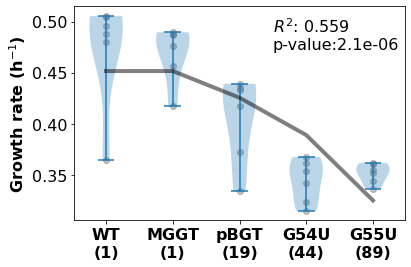

In [29]:
fig=plt.figure(figsize=(6,4))
fig.set_facecolor('white')
plt.rcParams.update({'font.size': 16})

xx=[]
xxL=[]
mumaxs=[]
mumaxsL=[]
mumax_means=[]

for istrain,this_strain in enumerate(single_strains):
    this_df=many_fits_single_res[many_fits_single_res["strain"]==this_strain]
    this_mumaxs=list(this_df["mumax"])
    this_x2=[strain_pcns[istrain]]*len(this_mumaxs)
    this_x=[istrain]*len(this_mumaxs)
    xxL=xxL+this_x2
    mumaxsL=mumaxsL+this_mumaxs
    mumax_means.append(np.mean(this_mumaxs))
    #xx.append(this_x)
    xx=xx+this_x
    mumaxs.append(this_mumaxs)
    plt.scatter(this_x,this_mumaxs,alpha=.5,c='gray')

lr_plot=linregress(xxL,mumaxsL)
lry_plot=[x*lr_plot.slope+lr_plot.intercept for x in xxL]
plt.plot(xx,lry_plot,'k',label="regression",lw=4,ls="-",alpha=.5)
plt.annotate(r"$R^2$: ""%s\np-value:%s"%(round(lr_plot.rvalue**2,3),"{:.1e}".format(lr_plot.pvalue)), xy=(0.6, 0.8), xycoords='axes fraction')

# lr_plot=linregress(strain_pcns,mumax_means)
# lry_plot=[x*lr_plot.slope+lr_plot.intercept for x in strain_pcns]
# plt.plot(range(0,5),lry_plot,'k',label="regression",lw=4,ls="-",alpha=.5)
# plt.annotate(r"$R^2$: ""%s\np-value:%s"%(round(lr_plot.rvalue**2,3),"{:.1e}".format(lr_plot.pvalue)), xy=(0.05, 0.05), xycoords='axes fraction',fontsize=12)


xdevs=[-.15,-.25,-13,-25,-25]
ydevs=[-.01,0,-0.005,0,-.03]
# for i, txt in enumerate(plt_strains_names):
#     plt.annotate(txt, (strain_pcns[i]+xdevs[i],mumax_means[i]+ydevs[i]),fontsize=12)


plotpcns=[int(round(x,0)) for x in strain_pcns]
single_strains2=["%s\n(%s)"%(s,p) for s,p in zip(single_strains,plotpcns)]
plt.xticks(range(0,5),labels=single_strains2,fontweight="bold")


plt.violinplot(mumaxs,positions=range(0,5))


######## upper axis
# ax=plt.axes()
# ax_t = ax.secondary_xaxis('top')
# ax_t.tick_params(direction = 'in',pad=0)
# ax_t.set_xticks(range(0,5))
# ax_t.set_xticklabels(plotpcns)


plt.ylabel("Growth rate (h$^{-1}$)",fontweight="bold")


plt.tight_layout()
out_fig_name=sfig_path+"sFig-12.pdf"
print("Saving fig as: \n",out_fig_name)
plt.savefig(out_fig_name,bbox_inches = 'tight',pad_inches = 0.1)
plt.show()


## Differences

In [23]:
%Rpush many_fits_single_res

In [24]:
%%R

many_fits_single_res.aov=aov(mumax ~ strain,many_fits_single_res)
many_fits_single_res.aov

summary(many_fits_single_res.aov)

pval=summary(many_fits_single_res.aov)[[1]][["Pr(>F)"]][[1]]
print("P-value is:")
print(pval)
if(pval<0.05){
    print("This means that there is a significant difference between the group variances/means")
}else{
    print("This means that there is NO significant differences between the group variances/means")
    
}



[1] "P-value is:"
[1] 2.915819e-07
[1] "This means that there is a significant difference between the group variances/means"


In [25]:
%%R

tuk_fit=TukeyHSD(many_fits_single_res.aov)
tuk_fit
print("Significant differences:")
df_tuk_fit=as.data.frame(tuk_fit$strain)
df_tuk_fit[df_tuk_fit["p adj"]<0.05,]


[1] "Significant differences:"
                 diff          lwr          upr        p adj
MGGT-G54U  0.12506524  0.066022297  0.184108177 1.536166e-05
pBGT-G54U  0.06123118  0.002188235  0.120274115 3.939318e-02
WT-G54U    0.12906574  0.070022802  0.188108682 9.404050e-06
MGGT-G55U  0.11753953  0.058496586  0.176582465 3.903779e-05
WT-G55U    0.12154003  0.062497091  0.180582970 2.374356e-05
pBGT-MGGT -0.06383406 -0.122877002 -0.004791122 2.947713e-02
WT-pBGT    0.06783457  0.008791627  0.126877507 1.865370e-02
